In [3]:
import pandas as pd 
import numpy as np

import matplotlib
matplotlib.use('TkAgg')

from ipywidgets import Button, HBox
import ipywidgets as widgets

import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib import cm
from matplotlib.colors import ListedColormap
from matplotlib import animation
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d.art3d import Line3DCollection

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import gaussian_kde

%matplotlib inline

# Importing Data

In [4]:
data = np.load('data/data_molecule/molecule.npz')
positions = data['positions']
angles = data['angles']
distances = data['distances']
atomTypes = data['atomTypes']
edges = data['edges']

# Visualizing Molecule

In [6]:
def plot_molecule(ax, molecule, type="color"):
    molecule_scatter = ax.scatter(molecule[:, 0], molecule[:, 1], molecule[:, 2], c="black", marker='o', linewidths=4)
    
    edge_midpoints = [(molecule[ai, 1] + molecule[bi, 1]) / 2 for ai, bi in edges]   
    norm = plt.Normalize(vmin=min(edge_midpoints), vmax=max(edge_midpoints))
    colors = [cm.viridis(norm(m)) for m in edge_midpoints]
    
    bond_line_collections = []
    for (ai, bi), color in zip(edges, colors):
        match type:
            case "color":
                bond_line_collections.append(
                    ax.plot(
                        [molecule[ai, 0], molecule[bi, 0]], 
                        [molecule[ai, 1], molecule[bi, 1]], 
                        [molecule[ai, 2], molecule[bi, 2]],
                        linewidth=4
                    )
                )
            case _:
                bond_line_collections.append(
                    ax.plot(
                        [molecule[ai, 0], molecule[bi, 0]], 
                        [molecule[ai, 1], molecule[bi, 1]], 
                        [molecule[ai, 2], molecule[bi, 2]],
                        linewidth=4,
                        color=color
                    )
                )
                
    return molecule_scatter, bond_line_collections

In [4]:
%matplotlib widget

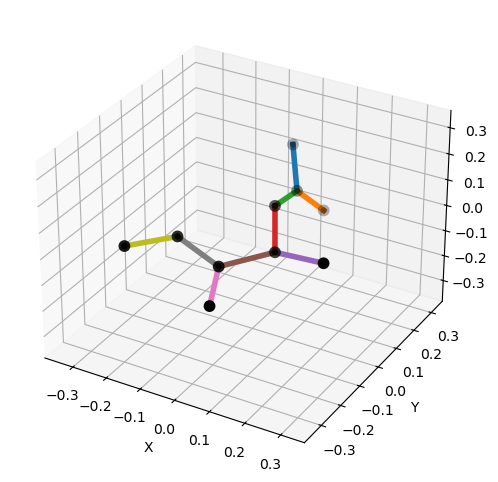

In [32]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
plot_molecule(ax, positions[0, :, :])

ax.set_xlim(np.min(positions), np.max(positions))
ax.set_ylim(np.min(positions), np.max(positions))
ax.set_zlim(np.min(positions), np.max(positions))

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

In [6]:
%matplotlib inline
plt.clf()

# Animating Molecule

In [34]:
%matplotlib widget

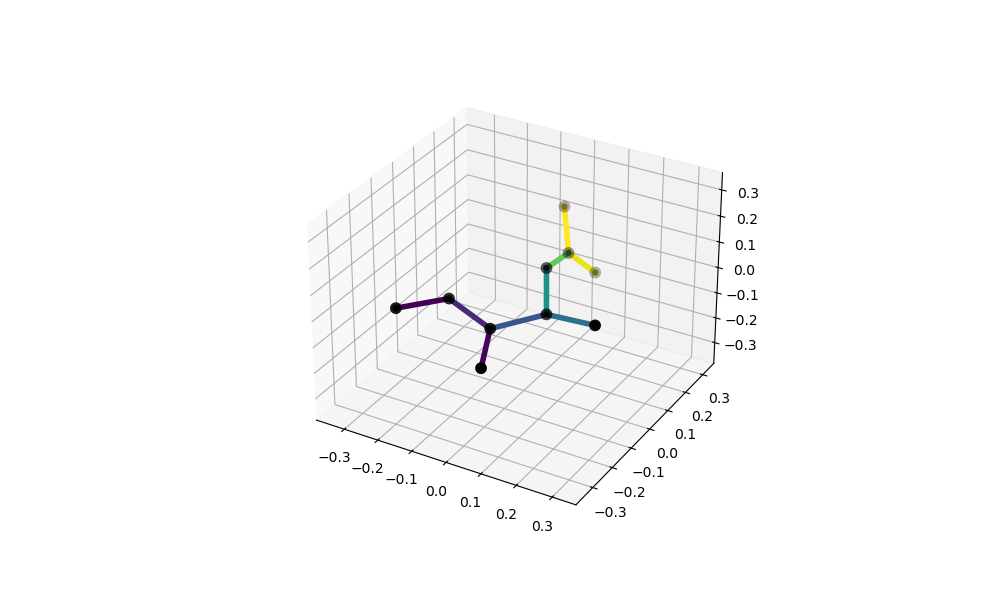

In [17]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

molecule = positions[0, :, :]
atoms, bonds = plot_molecule(ax, molecule, type="depth")
bonds = [group[0] for group in bonds]

ax.set_xlim(np.min(positions), np.max(positions))
ax.set_ylim(np.min(positions), np.max(positions))
ax.set_zlim(np.min(positions), np.max(positions))

def update(frame):
    ax.set_title(f"Molecule at t={frame}")
    mol = positions[frame, :, :]

    atoms._offsets3d = (mol[:, 0], mol[:, 1], mol[:, 2])

    edge_midpoints = [(mol[ai, 2] + mol[bi, 2]) / 2 for ai, bi in edges]
    norm = plt.Normalize(vmin=np.min(edge_midpoints), vmax=np.max(edge_midpoints))
    colors = [cm.viridis(norm(m)) for m in edge_midpoints]

    for i, ((ai, bi), line) in enumerate(zip(edges, bonds)):
        line.set_data([mol[ai, 0], mol[bi, 0]], [mol[ai, 1], mol[bi, 1]])
        line.set_3d_properties([mol[ai, 2], mol[bi, 2]])
        line.set_color(colors[i])

    return [atoms] + bonds

ani = animation.FuncAnimation(fig, update, frames=100, interval=300, blit=False)

start_button = Button(description="Start", button_style='success')
stop_button = Button(description="Stop", button_style='danger')

def start_animation(b):
    ani.event_source.start()

def stop_animation(b):
    ani.event_source.stop()

start_button.on_click(start_animation)
stop_button.on_click(stop_animation)

display(HBox([start_button, stop_button]))

In [9]:
%matplotlib inline
ani.pause()

# Angle Histogram

In [13]:
phi = angles[:, 1]
psi = angles[:, 0]

def create_angles_hist(ax, phi, psi, alpha_phi=1.0, alpha_psi=1.0):
    hist1 = ax.hist(phi, bins=90, range=(-np.pi, np.pi), density=True, color="red", alpha=alpha_phi, label="$\phi$")
    hist2 = ax.hist(psi, bins=90, range=(-np.pi, np.pi), density=True, color="black", alpha=alpha_psi, label="$\psi$")
    
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)    
    ax.grid(True)
    
    theta = np.linspace(0, 2*np.pi, 9)
    labels_degrees = [f'{int(np.degrees(t))}' for t in theta]
    labels = [
        r"$0$",
        r"$\frac{\pi}{4}$",
        r"$\frac{\pi}{2}$",
        r"$\frac{3\pi}{4}$",
        r"-$\pi$ \ $\pi$",
        r"$-\frac{3\pi}{4}$",
        r"$-\frac{\pi}{2}$",
        r"$-\frac{\pi}{4}$",
        ""
    ]
    
    ax.set_xticks(theta)
    ax.set_xticklabels(labels)
    ax.legend(bbox_to_anchor=(1.33,0.2), frameon=False)
    return fig, ax

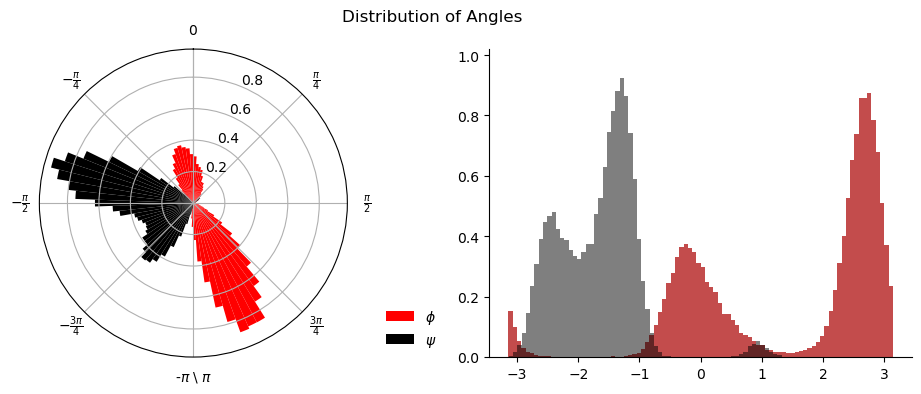

In [12]:
fig = plt.figure(figsize=(12, 4))

ax0 = fig.add_subplot(1, 2, 1, projection='polar')
ax1 = fig.add_subplot(1, 2, 2)

create_angles_hist(ax0, phi, psi)

ax1.hist(phi, bins=90, alpha=0.7, color="#AA0000", density=True)
ax1.hist(psi, bins=90, alpha=0.5, color="black", density=True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(0,1.02)


fig.suptitle("Distribution of Angles");

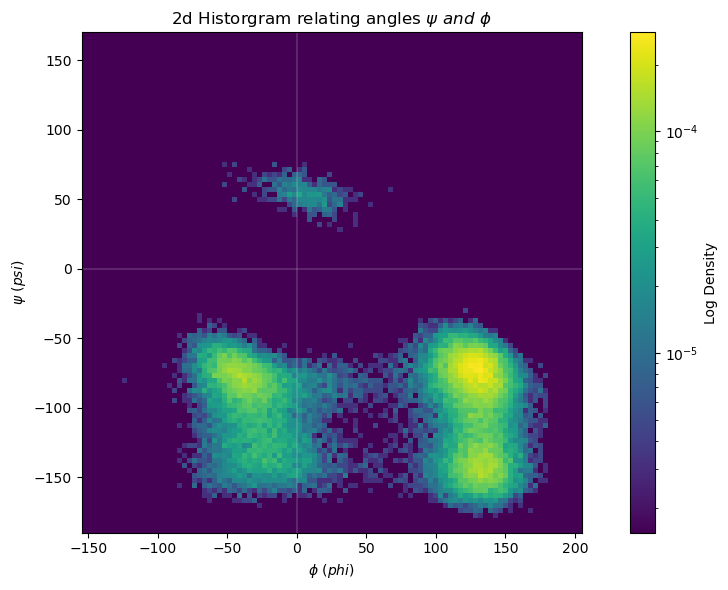

In [16]:
# Plot contours
phi_deg = np.degrees(phi)
psi_deg = np.degrees(psi)
phi_shift = 25
psi_shift = -10
phi_shifted = (phi_deg - phi_shift + 180) % 360 - 180
psi_shifted = (psi_deg - psi_shift + 180) % 360 - 180

plt.figure(figsize=(10, 6))
H, xedges, yedges = np.histogram2d(
    phi_shifted, 
    psi_deg, 
    bins=100,
    range=[[-180 + phi_shift, 180 + phi_shift], [-180 + psi_shift, 180 + psi_shift]], 
    density=True,
)
H[H == 0] = H[H != 0].min()

plt.imshow(H.T, origin='lower',
           extent=[-180 + phi_shift, 180 + phi_shift, -180 + psi_shift, 180 + psi_shift],
           cmap='viridis', norm="log", interpolation=None
)

cbar = plt.colorbar(label='Log Density')
plt.xlabel("$\phi \ (phi)$")
plt.ylabel("$\psi \ (psi)$")
plt.title("2d Historgram relating angles $\psi \ and\  \phi$")

plt.xlim([-180 + phi_shift, 180 + phi_shift])
plt.ylim([-180 + psi_shift, 180 + psi_shift])
plt.plot([0, 0], [-180 + psi_shift, 180 + psi_shift], c='white', linewidth=0.2)
plt.plot([-180 + phi_shift, 180 + phi_shift], [0, 0], c='white', linewidth=0.2)
# plt.grid(True)
plt.tight_layout()
ticks = cbar.get_ticks()
plt.show()

# Angle Animation

In [15]:
%matplotlib widget

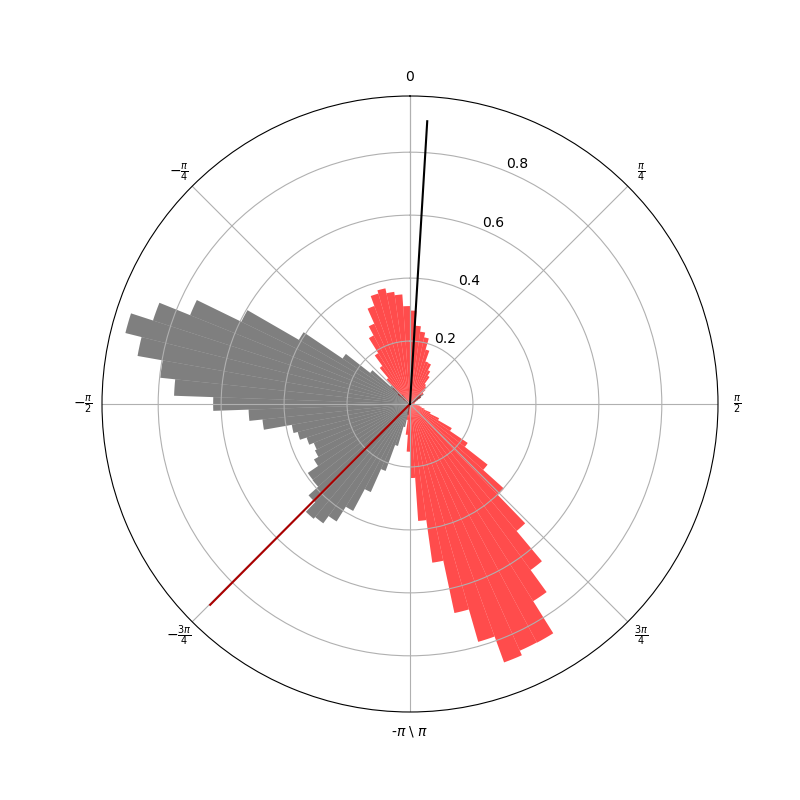

In [16]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='polar')

create_angles_hist(ax, phi, psi, alpha_phi=0.7, alpha_psi=0.5)

def init(ax):
    phi_angle, psi_angle = angles[0]
    line_phi, = ax.plot([0, phi_angle], [0, 0.9], color="#AA0000")
    line_psi, = ax.plot([0, psi_angle], [0, 0.9], color="black")
    return line_phi, line_psi

def update(i):
    phi_angle, psi_angle = phi[i], psi[i]

    line_phi.set_data([0, phi_angle], [0, 0.9])
    line_psi.set_data([0, psi_angle], [0, 0.9])

    ax.set_title(f"Time Step {i}")

    return line_phi, line_psi

line_phi, line_psi = init(ax)

ani = animation.FuncAnimation(fig, update, frames=100, blit=True, repeat=True)


start_button = Button(description="Start", button_style='success')
stop_button = Button(description="Stop", button_style='danger')

def start_animation(b):
    ani.event_source.start()

def stop_animation(b):
    ani.event_source.stop()

start_button.on_click(start_animation)
stop_button.on_click(stop_animation)

display(HBox([start_button, stop_button]))

In [7]:
plt.clf()
ani.pause()
%matplotlib inline

# PCA of Distances

In [6]:
X = distances
n_samples = X.shape[0]
X_centered = X - np.mean(X, axis=0)
pca = PCA()
X_transformed = pca.fit_transform(X_centered)

# We center the data and compute the sample covariance matrix.
cov_matrix = np.dot(X_centered.T, X_centered) / n_samples
spectrum = [
    np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector))
    for eigenvector in pca.components_
]

cumsum = np.cumsum([0] + spectrum)
cumsum /= cumsum[-1]

<Figure size 1200x400 with 0 Axes>

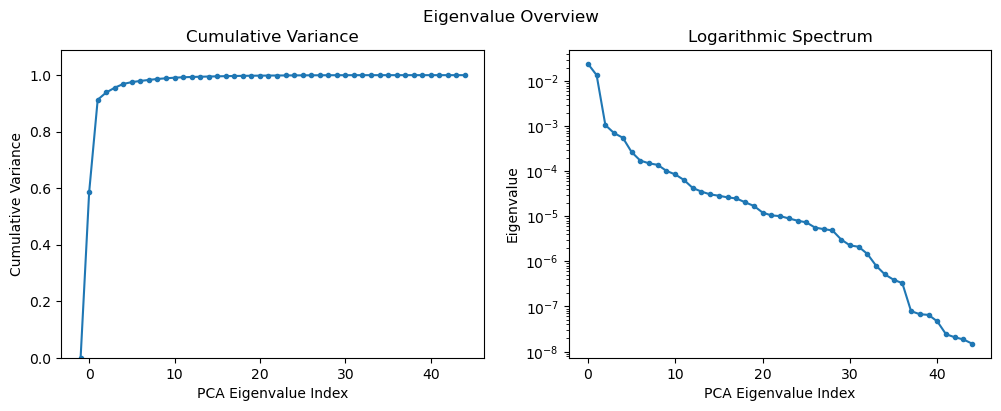

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
ax = axs[0]
ax.plot(np.arange(-1, len(cumsum) - 1), cumsum, marker='.')
ax.set_ylim(0, 1.09)
ax.set_xlabel("PCA Eigenvalue Index")
ax.set_ylabel("Cumulative Variance")
ax.set_title("Cumulative Variance")

ax = axs[1]
ax.plot(np.arange(len(spectrum)), spectrum, marker='.')
ax.set_yscale("log")
ax.set_xlabel("PCA Eigenvalue Index")
ax.set_ylabel("Eigenvalue")
ax.set_title("Logarithmic Spectrum")

fig.suptitle('Eigenvalue Overview');

In [12]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
phi_psi_cluster_labels = kmeans.fit_predict(angles)

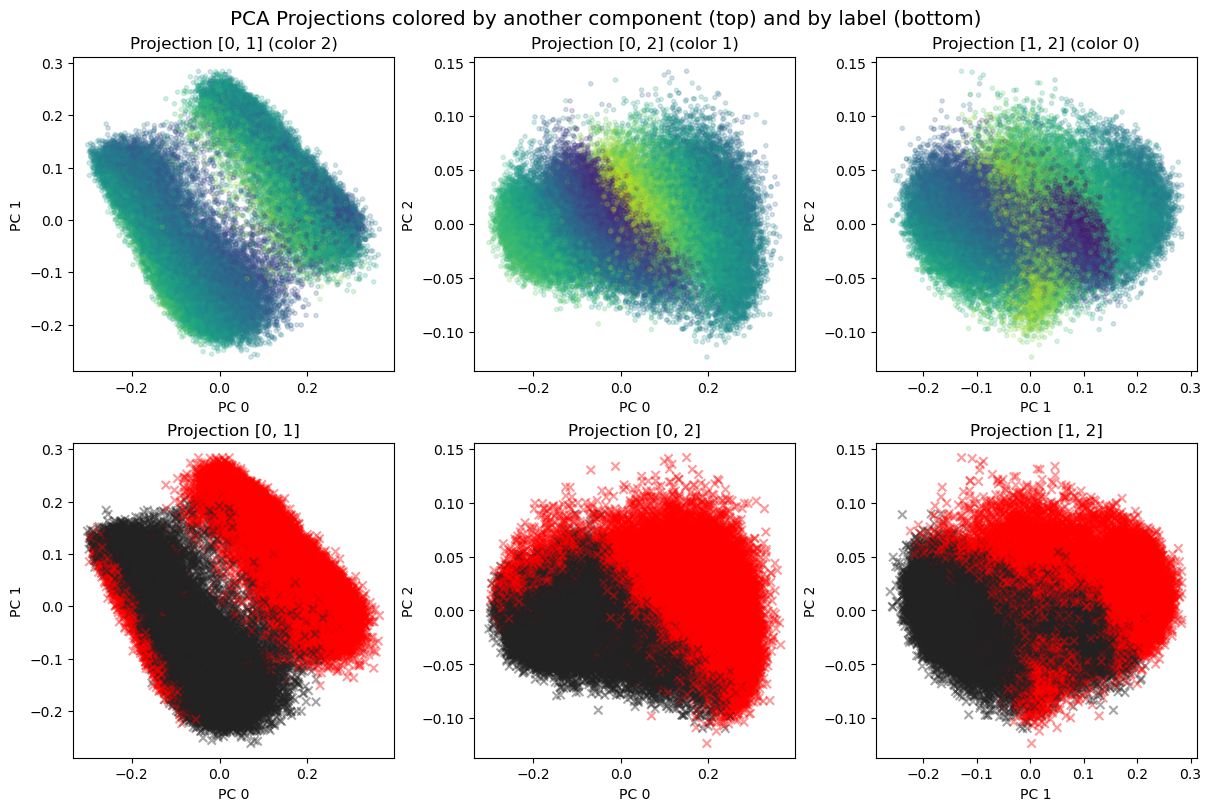

In [22]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)

two_color_cmap = ListedColormap(["#222222", "red"])

for ax, (i, j, k) in zip(axs[0], [(0,1, 2), (0,2, 1), (1,2, 0)]):
    ax.scatter(X_transformed[:, i], X_transformed[:, j], c=X_transformed[:, k], marker='.', alpha=0.2, cmap=cm.viridis)
    ax.set_xlabel(f'PC {i}')
    ax.set_ylabel(f'PC {j}')
    ax.set_title(f'Projection [{i}, {j}] (color {k})')

for ax, (i, j, k) in zip(axs[1], [(0,1, 2), (0,2, 1), (1,2, 0)]):
    ax.scatter(X_transformed[:, i], X_transformed[:, j], c=phi_psi_cluster_labels, cmap=two_color_cmap, marker='x', alpha=0.4);
    ax.set_xlabel(f'PC {i}')
    ax.set_ylabel(f'PC {j}')
    ax.set_title(f'Projection [{i}, {j}]')
    
fig.suptitle("PCA Projections colored by another component (top) and by label (bottom)", size="x-large");
plt.show()

In [181]:
%matplotlib widget

In [5]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_transformed[:, 0], X_transformed[:, 1], X_transformed[:, 2], c=X_transformed[:, 3], alpha=0.1, cmap=cm.magma)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('3D PCA Projection')
plt.show()

In [107]:
%matplotlib inline

# Length Distribution

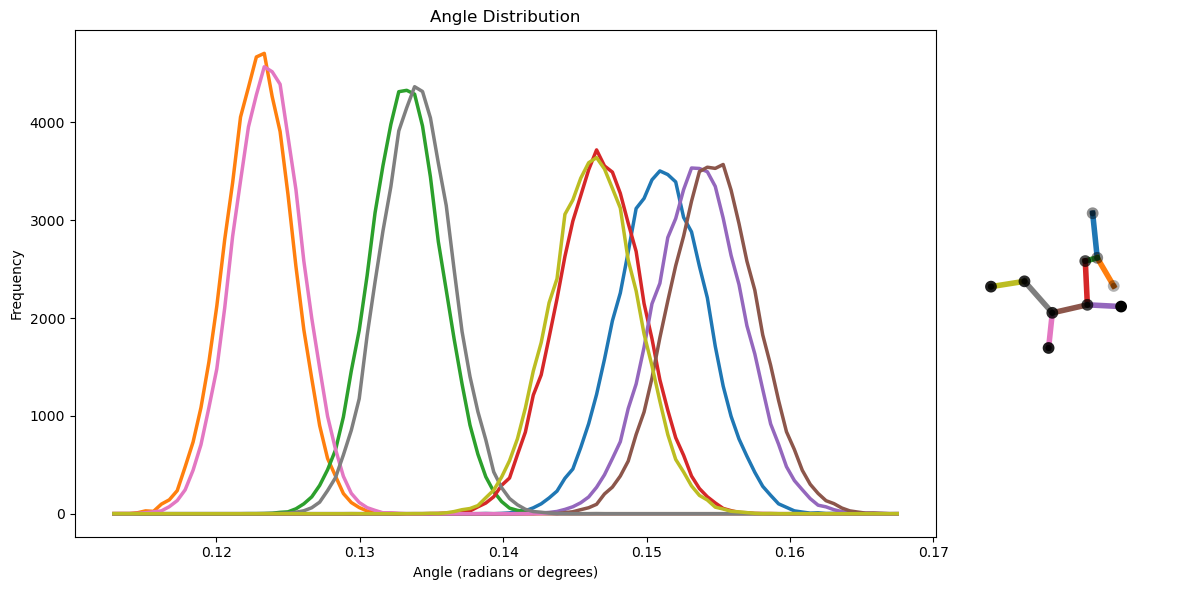

In [11]:
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])
ax_mol = fig.add_subplot(gs[1], projection='3d')
ax_hist = fig.add_subplot(gs[0])

molecule = positions[0, :, :]
plot_molecule(ax_mol, molecule, type="color")
ax_mol.grid(False)
ax_mol.axis("off")

start = positions[:, edges[:, 0], :]
end = positions[:, edges[:, 1], :]
lengths = np.linalg.norm(start - end, axis=2)

num_bins = 100
all_data = lengths.ravel()
bin_edges = np.linspace(all_data.min(), all_data.max(), num_bins + 1)

for edge_idx in range(lengths.shape[1]):
    hist, _ = np.histogram(lengths[:, edge_idx], bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    ax_hist.plot(bin_centers, hist, label=f'Edge {edge_idx + 1}', linewidth=2.5)

ax_hist.set_title("Angle Distribution")
ax_hist.set_xlabel("Angle (radians or degrees)")
ax_hist.set_ylabel("Frequency")
plt.tight_layout()
plt.show()